# 13 — Can we tell reverters from runners at the trigger? (causal features)

User's idea: classify pumps by features known AT the trigger, learn on the past
which kinds revert vs run, and in the future trade only the reverting kinds.

Honest setup:
- 12 **causal** features per pump (speed r1..r30, acceleration, volume surge,
  vol regime, candle range, distance from recent high/low) — all known at the
  first trigger.
- Label = the scale-in net PnL (from the future) — used ONLY to train.
- **Time split**: train on the earliest 60% of events, test on the latest 40%
  (a real out-of-sample by time). Model never sees test labels.
- Question: on the TEST half, do the model's high-scored pumps actually revert
  more than average?

In [1]:
import sys; sys.path.insert(0, '.')
from _lab import *
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance

d = np.load('_out/pump_features_3y.npz', allow_pickle=True)
X, y, ts, runup = d['X'], d['y'], d['ts'], d['runup']
names = list(d['feat_names'])
order = np.argsort(ts)
X, y, ts, runup = X[order], y[order], ts[order], runup[order]
cut = int(len(y) * 0.6)
Xtr, ytr, Xte, yte = X[:cut], y[:cut], X[cut:], y[cut:]
print(f'train {len(ytr)} events ({pd.to_datetime(ts[0]).date()} .. {pd.to_datetime(ts[cut-1]).date()})')
print(f'test  {len(yte)} events ({pd.to_datetime(ts[cut]).date()} .. {pd.to_datetime(ts[-1]).date()})')
print(f'test baseline (trade ALL): mean {yte.mean()*100:+.2f}%  win {(yte>0).mean()*100:.0f}%')

train 4500 events (2024-01-01 .. 2025-03-02)
test  3000 events (2025-03-02 .. 2026-04-30)
test baseline (trade ALL): mean +1.10%  win 54%


In [2]:
model = HistGradientBoostingRegressor(max_depth=3, learning_rate=0.05,
                                      max_iter=300, l2_regularization=1.0,
                                      min_samples_leaf=50, random_state=0)
model.fit(Xtr, ytr)
pred = model.predict(Xte)
corr = np.corrcoef(pred, yte)[0, 1]
print(f'OOS corr(predicted, actual pnl): {corr:+.3f}')

# decile analysis on test: sort by predicted score, mean ACTUAL pnl per decile
dec = pd.qcut(pred, 10, labels=False, duplicates='drop')
print('\ntest decile (by predicted score) -> realized mean net pnl %:')
tab = pd.DataFrame({'dec': dec, 'pnl': yte, 'runup': runup[cut:]}).groupby('dec').agg(
    pnl_pct=('pnl', lambda s: s.mean()*100), win=('pnl', lambda s: (s>0).mean()*100),
    runup_pct=('runup', lambda s: s.mean()*100), n=('pnl','size'))
print(tab.round(2).to_string())

OOS corr(predicted, actual pnl): +0.298

test decile (by predicted score) -> realized mean net pnl %:
     pnl_pct    win  runup_pct    n
dec                                
0      -2.35  16.00      16.95  300
1      -1.06  30.67       5.73  300
2       0.43  45.67       7.10  300
3       1.19  56.00       5.98  300
4       1.54  60.33       6.46  300
5       1.92  66.33       6.69  300
6       2.02  65.33       7.15  300
7       2.62  69.67       5.98  300
8       2.23  66.00       7.39  300
9       2.49  67.00       7.65  300


[saved] notebooks\pump\_out\13_classifier.png


WindowsPath('C:/projects/researchlab/notebooks/pump/_out/13_classifier.png')

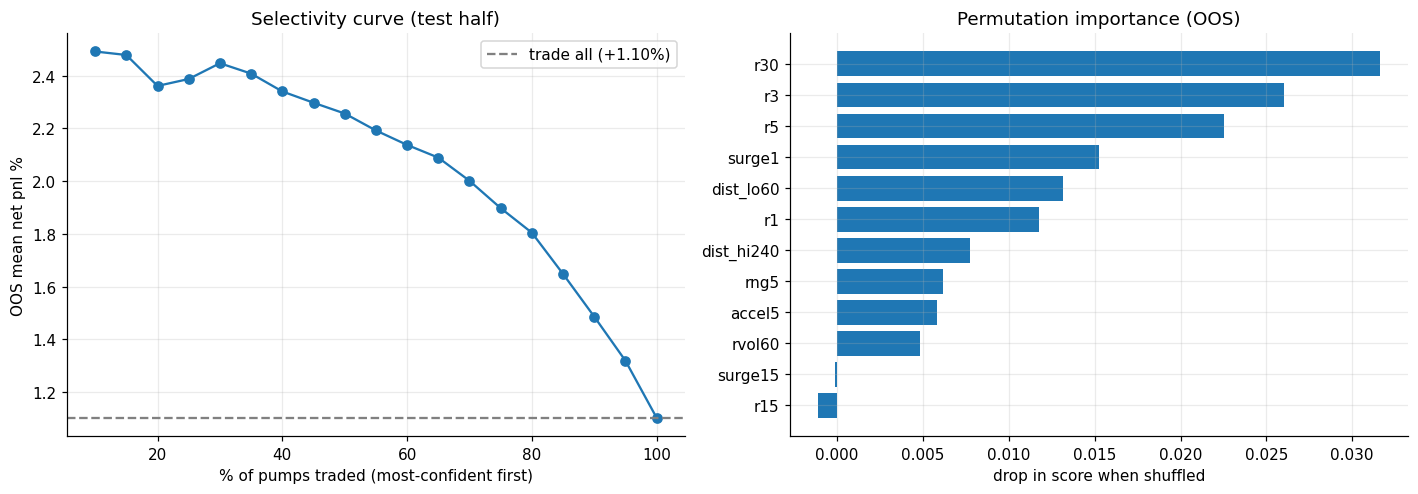

In [3]:
# selectivity curve: trade only the top-f fraction by predicted score (OOS)
fracs = np.linspace(0.1, 1.0, 19)
thr_means, thr_wins = [], []
sidx = np.argsort(-pred)
for f in fracs:
    k = max(1, int(len(pred) * f))
    sel = sidx[:k]
    thr_means.append(yte[sel].mean() * 100)
    thr_wins.append((yte[sel] > 0).mean() * 100)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.6))
a1.plot(fracs*100, thr_means, 'o-')
a1.axhline(yte.mean()*100, color='gray', ls='--', label=f'trade all ({yte.mean()*100:+.2f}%)')
a1.set_xlabel('% of pumps traded (most-confident first)'); a1.set_ylabel('OOS mean net pnl %')
a1.set_title('Selectivity curve (test half)'); a1.legend()
# feature importance
imp = permutation_importance(model, Xte, yte, n_repeats=8, random_state=0)
o2 = np.argsort(imp.importances_mean)
a2.barh([names[i] for i in o2], imp.importances_mean[o2], color='tab:blue')
a2.set_title('Permutation importance (OOS)'); a2.set_xlabel('drop in score when shuffled')
show('13_classifier')

In [4]:
# headline: trade the top half the model likes, vs trade all (OOS)
for f in [1.0, 0.5, 0.3]:
    k = max(1, int(len(pred)*f)); sel = np.argsort(-pred)[:k]
    print(f'trade top {int(f*100):>3}%: mean {yte[sel].mean()*100:+.2f}%  win {(yte[sel]>0).mean()*100:.0f}%  '
          f'avg runup {runup[cut:][sel].mean()*100:.1f}%')

trade top 100%: mean +1.10%  win 54%  avg runup 7.7%
trade top  50%: mean +2.26%  win 67%  avg runup 7.0%
trade top  30%: mean +2.45%  win 68%  avg runup 7.0%
